#Problem 5b

In [4]:
import numpy as np
from matplotlib import pyplot as plt

# Number of samples, list to catch z values
n = 10 ** 5
z_values = []

#Generating my samples
u =np.random.uniform(0, 1, n)

#define my inverse sampling function
def inverse(u):
    z = 1 - np.sqrt(1 - u)
    z_values.append(z)

#Actually running the simulation
for value in u:
    inverse(value)

#Calculate the sample mean
sample_mean = sum(z_values) / len(z_values)
theor_mean = 1 / 3

#Shwo the Sample and Theoretical means
print(f"Sample Mean: {sample_mean: .4f}")
print(f"Theoretical Mean: {theor_mean: .4f}")


Sample Mean:  0.3328
Theoretical Mean:  0.3333


#Problem 5c

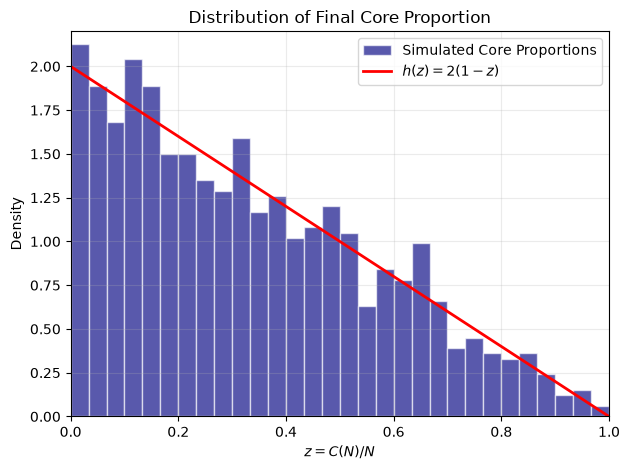

Empirical Mean: 0.33069
Theoretical Mean: 0.33333
Empirical CV: 0.71750
Theoretical CV: 0.70711
Smallest Core in Sample: 1
Largest Core in Sample: 9803


In [17]:
#Problem set-up
mu = 1
n = 10 ** 4
r = 10 ** 3
core_counts = np.ones(r, dtype = int)

#simulate the networks
for i in range(3, n):
    prob = mu * (core_counts / i)
    core_counts += np.random.binomial(1, prob)

#Final ratios
z = core_counts / n

#Calculate the empirical stats
emp_mean = np.mean(z) #lets just use numpy
emp_cv = np.std(z) / emp_mean

min_core = min(core_counts)
max_core = max(core_counts)

#import theoretical stats
theor_mean = 1 / 3
theor_cv = 1 / np.sqrt(2)

#plot the density of h
z_grid = np.linspace(0, 1, 31)
h_grid = 2 * (1 - z_grid)

#plot!
plt.hist(
    z,
    bins = np.linspace(0, 1, 31),
    density = True,
    color = "navy",
    alpha = 0.65,
    edgecolor = "white",
    label = "Simulated Core Proportions"
)

plt. plot(
    z_grid,
    h_grid,
    color = "red",
    linewidth = 2,
    label = r"$h(z)=2(1-z)$"
)

plt.xlim(0, 1)
plt.ylim(0, 2.2)
plt.xlabel(r"$z=C(N)/N$")
plt.ylabel("Density")
plt.title("Distribution of Final Core Proportion")
plt.grid(alpha = 0.25)
plt.legend()
plt.tight_layout()
plt.show()


#Report the statistics
print(f"Empirical Mean:{emp_mean: .5f}")
print(f"Theoretical Mean:{theor_mean: .5f}")

print(f"Empirical CV:{emp_cv: .5f}")
print(f"Theoretical CV:{theor_cv: .5f}")

print(f"Smallest Core in Sample: {min_core}")
print(f"Largest Core in Sample: {max_core}")

##Commenting on the average core size
The average core proportion across all 1000 networks turns out to be 1/3, which is the ratio of cores to nodes we started each network with! However, this does not imply that any given network settles towards the 1/3 ratio, as we can see in the distribution and the wild spread between the network with the most cores and then one with the least. Thus, the average may describe the collection of networks pretty well, but may not represent any of the 1000 networks individually that well at all.